In [1]:
import numpy as np
import matplotlib.pyplot as plt
import strawberryfields as sf
from strawberryfields.ops import*
import qkd_sf as qsf

## RR

Holevo Calculation using SF

In [2]:
def von_neumann_entropy(rho):
        eigvals = np.linalg.eigvalsh(rho)

        # Remove numerical noise
        eigvals = eigvals[eigvals > 1e-12]

        return -np.sum(eigvals * np.log2(eigvals))

def eve_state_RR(eta, var, key_len, cutoff=5, nbins=5):

    theta = np.arccos(np.sqrt(eta))

    # First store Eve states and Bob outcomes
    eve_states = []
    bob_results = []

    for i in range(key_len):

        prog = sf.Program(2)

        with prog.context as q:

            Vac | q[0]

            alpha_p = np.random.normal(0, np.sqrt(var))
            alpha_q = np.random.normal(0, np.sqrt(var))

            Xgate(alpha_q) | q[0]
            Zgate(alpha_p) | q[0]

            Vac | q[1]

            BSgate(theta, 0.0) | (q[0], q[1])

            MeasureHomodyne(0) | q[0]

        eng = sf.Engine("fock", backend_options={"cutoff_dim": cutoff})

        result = eng.run(prog)
        b = result.samples[0][0]

        # Eve's conditional state after Bob's measurement
        rho_E_i = result.state.reduced_dm([1])

        bob_results.append(b)
        eve_states.append(rho_E_i)

        eng.reset()
        print(f"\rProgress: {i+1}/{key_len}", end="", flush=True)
    bob_results = np.array(bob_results)
    
    # ------------------------------------------------
    # Unconditional Eve state
    # ------------------------------------------------

    rho_E = np.mean(eve_states, axis=0)

    S_E = von_neumann_entropy(rho_E)

    # ------------------------------------------------
    # Bin Bob's results
    # ------------------------------------------------

    bins = np.linspace(np.min(bob_results), np.max(bob_results), nbins + 1)
    S_E_given_B = 0.0

    for j in range(nbins):

        if j == nbins - 1:
            indices = np.where((bob_results >= bins[j]) & (bob_results <= bins[j+1]))[0]
        else:
            indices = np.where((bob_results >= bins[j]) & (bob_results < bins[j+1]))[0]

        if len(indices) == 0:
            continue

        # Conditional Eve density matrix for this bin
        rho_E_b = np.mean(
            [eve_states[i] for i in indices],
            axis=0)

        # Probability of this Bob bin
        p_b = len(indices) / key_len

        # Entropy of conditional Eve state
        S_E_b = von_neumann_entropy(rho_E_b)

        S_E_given_B += p_b * S_E_b

    chi_EB = S_E - S_E_given_B

    return rho_E, chi_EB

In [ ]:
rho_E, S_E, S_E_given_B, chi_EB = eve_state_RR(
    eta=0.1,
    var=40,
    key_len=1000,
    cutoff=20,
    nbins=50)
print()
print("S(E)       =", S_E)
print("S(E|B)     =", S_E_given_B)
print("Chi(E;B)   =", chi_EB)

Progress: 600/600
S(E)       = 4.236073460075105
S(E|B)     = 2.9411710372576745
Chi(E;B)   = 1.2949024228174308


In [36]:
def G(x):
    if x < 1e-12:
        return 0.0
    return (x + 1)*np.log2(x + 1) - x*np.log2(x)

lambda1, lambda2 = qsf.lambda_RR(40, 0.1)

S_E_theory = G((lambda1 - 1)/2)
S_Econd_theory = G((lambda2 - 1)/2)
chi_theory = S_E_theory - S_Econd_theory

print("S(E) theory       =", S_E_theory)
print("S(E|B) theory     =", S_Econd_theory)
print("Chi(E;B) theory   =", chi_theory)


S(E) theory       = 5.651972729466394
S(E|B) theory     = 4.564440378298496
Chi(E;B) theory   = 1.0875323511678978


In [4]:
eta = 0.1
key_len = 100
sigma_grid = np.linspace(0,10,5)
holevo_grid=np.zeros((5))
for i, sigma in enumerate(sigma_grid):
    rho_E, chi_EB = eve_state_RR(eta=0.1,
        var=sigma**2,
        key_len=100,
        cutoff=25,
        nbins=10)
    holevo_grid[i] = chi_EB
    print(f"\rProgress: {i+1}/{len(sigma_grid)}", end="", flush=True)
    

Progress: 5/5/100

SKR Calculation

In [7]:
eta = 0.1
keylen=10000
size = 5
sigma_grid = np.linspace(0,10,size)
I_grid_RR = np.zeros((size))
holevo_th_grid_RR = np.zeros((size))

for i,sigma in enumerate(sigma_grid):
    alice_bitstr, bob_bitstr = qsf.sf_protocol(eta, sigma**2, keylen)
    rho = np.corrcoef(alice_bitstr, bob_bitstr)[0, 1]
    I_AB = -0.5 * np.log2(1 - rho**2)
    I_grid_RR[i] = I_AB
    holevo_th_grid_RR[i] = qsf.theoretical_holevo_bound(*qsf.lambda_RR(sigma**2, eta))
    
    print(f"\rProgress: {i+1}/{len(sigma_grid)}", end="", flush=True)

    
    

Progress: 1/5

c:\Users\kmits\Desktop\github\Quantum-Communications-Internship-IRIDA-\.venv\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
c:\Users\kmits\Desktop\github\Quantum-Communications-Internship-IRIDA-\.venv\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide


Progress: 5/5

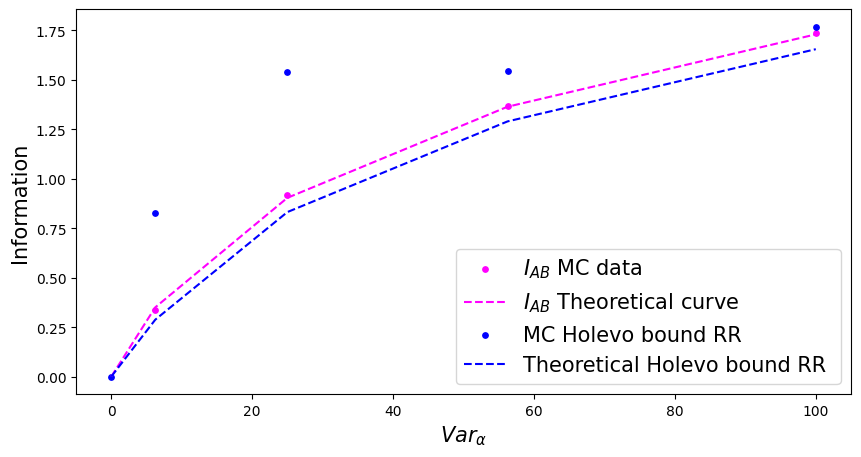

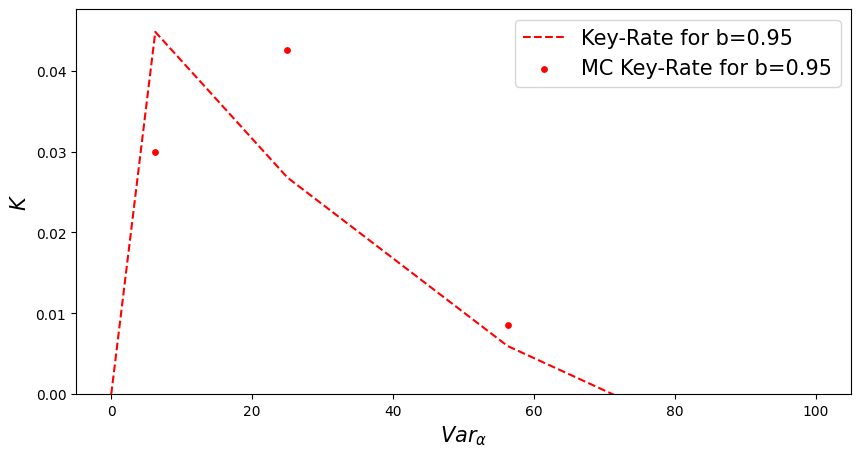

In [8]:
b = 0.95
sigma_grid2 = np.linspace(0,10,5)
size = 5
sigma_grid = np.linspace(0,10,size)
fig = plt.figure(figsize=(10,5), dpi=100)
plt.scatter(sigma_grid**2, I_grid_RR, s=15, color = 'magenta', label=r'$I_{AB}$ MC data')
plt.plot(sigma_grid**2, qsf.theoretical_I_AB(sigma_grid**2, eta), '--', color='magenta', label=r'$I_{AB}$ Theoretical curve')
plt.scatter(sigma_grid2**2, holevo_grid, s=15, color = 'blue', label = 'MC Holevo bound RR')
plt.plot(sigma_grid**2, holevo_th_grid_RR, 'b--', label = 'Theoretical Holevo bound RR ')
plt.xlabel(r'$Var_{{\alpha}}$', fontsize=15)
plt.ylabel(r'Information', fontsize=15)
plt.legend(fontsize=15)

b = 0.95
fig = plt.figure(figsize=(10,5), dpi=100)
plt.plot(sigma_grid**2, qsf.key_rate(b, qsf.theoretical_I_AB(sigma_grid**2, eta), holevo_th_grid_RR), '--r', label = f'Key-Rate for b={b}')
plt.scatter(sigma_grid**2, qsf.key_rate(b, I_grid_RR, holevo_th_grid_RR), s=15, color = 'red', label = f'MC Key-Rate for b={b}')
plt.xlabel(r'$Var_{{\alpha}}$', fontsize=15)
plt.ylim(0)
plt.ylabel(r'$K$', fontsize=15)
plt.legend(fontsize=15)


## DR

Holevo bound calculation using SF

In [ ]:
def eve_state_DR(eta, var, key_len):
    cutoff = 20
    rho_E = np.zeros((cutoff, cutoff), dtype=complex)
    for i in range(key_len):
        prog = sf.Program(2)
        theta = np.arccos(np.sqrt(eta))
        with prog.context as q:

            # Input state on Alice's mode
            Vac | q[0]
            alpha_p = np.random.normal(0, np.sqrt(var))
            alpha_q = np.random.normal(0, np.sqrt(var))
            Xgate(alpha_q) | q[0]
            Zgate(alpha_p) | q[0]

            # Vacuum entering unused beam-splitter port
            Vac | q[1]
            # Beam splitter
            BSgate(theta, 0.0) | (q[0], q[1])

        eng = sf.Engine("fock", backend_options={"cutoff_dim": cutoff})
        result = eng.run(prog)
        rho_E += result.state.reduced_dm([1])/key_len
        eng.reset()

    return von_neumann_entropy(rho_E)


0.2452465815198106


In [ ]:
def G(x):
    if x <= 0:
        return 0.0
    return (x + 1) * np.log2(x + 1) - x * np.log2(x)


def symplectic_eigenvalue(gamma):
    return np.sqrt(np.linalg.det(gamma))


def eve_covariance(var_a, eta):
    V_E = 1 + (1 - eta) * var_a

    return np.array([[V_E, 0], [0, V_E]])


def eve_conditional_covariance_DR(var_a, eta):
    V_E = 1 + (1 - eta) * var_a

    # Alice reveals only one quadrature
    return np.array([[1, 0], [0, V_E]])


def chi_DR(var_a, eta):

    # Unconditional Eve state
    #gamma_E = eve_covariance(var_a, eta)
    # Alice modulation
    N=100000
    aq = np.random.normal(0, np.sqrt(var_a), N)
    ap = np.random.normal(0, np.sqrt(var_a), N)

    # Eve vacuum noise
    nq = np.random.normal(0, 1, N)
    np_ = np.random.normal(0, 1, N)

    # Eve quadratures
    qe = np.sqrt(1 - eta) * aq + np.sqrt(eta) * nq
    pe = np.sqrt(1 - eta) * ap + np.sqrt(eta) * np_

    # Numerical covariance matrix
    gamma_E = np.cov(np.vstack([qe, pe]))
    lambda_E = symplectic_eigenvalue(gamma_E)

    # Eve conditioned on Alice's measured quadrature
    gamma_E_cond = eve_conditional_covariance_DR(var_a, eta)
    lambda_cond = symplectic_eigenvalue(gamma_E_cond)

    S_E = G((lambda_E - 1) / 2)
    S_E_cond = G((lambda_cond - 1) / 2)

    chi = S_E - S_E_cond

    return chi, lambda_E, lambda_cond

In [ ]:
eta = 0.6
key_len = 10000
sigma_grid = np.linspace(0,10,5)
holevo_grid_DR = np.zeros((5))
for i, sigma in enumerate(sigma_grid):
    chi_EA = eve_state_DR(eta, sigma**2, key_len)
    holevo_grid_DR[i] = chi_EA
    print(f"\rProgress: {i+1}/{len(sigma_grid)}", end="", flush=True)
    

Progress: 5/5

SKR Calculation

In [27]:
eta = 0.6
keylen=10000
size = 11
sigma_grid = np.linspace(0,10,size)
I_grid_DR = np.zeros((size))
holevo_th_grid_DR = np.zeros((size))
for i,sigma in enumerate(sigma_grid):
    alice_bitstr, bob_bitstr = qsf.sf_protocol(eta, sigma**2, keylen)
    rho = np.corrcoef(alice_bitstr, bob_bitstr)[0, 1]
    I_AB = -0.5 * np.log2(1 - rho**2)
    I_grid_DR[i] = I_AB
    chi, lambda_E, lambda_cond = chi_DR(sigma**2, eta)
    holevo_th_grid_DR[i] = chi
    
    print(f"\rProgress: {i+1}/{len(sigma_grid)}", end="", flush=True)

    
    

c:\Users\kmits\Desktop\github\Quantum-Communications-Internship-IRIDA-\.venv\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
c:\Users\kmits\Desktop\github\Quantum-Communications-Internship-IRIDA-\.venv\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide


NameError: name 'N' is not defined

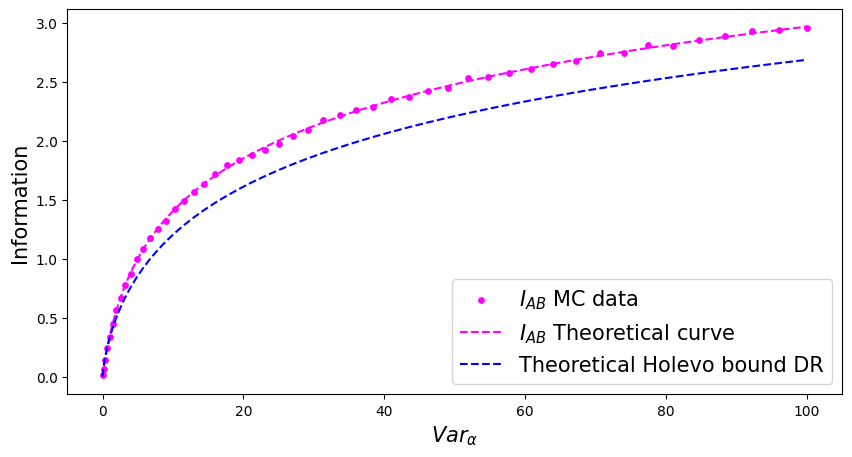

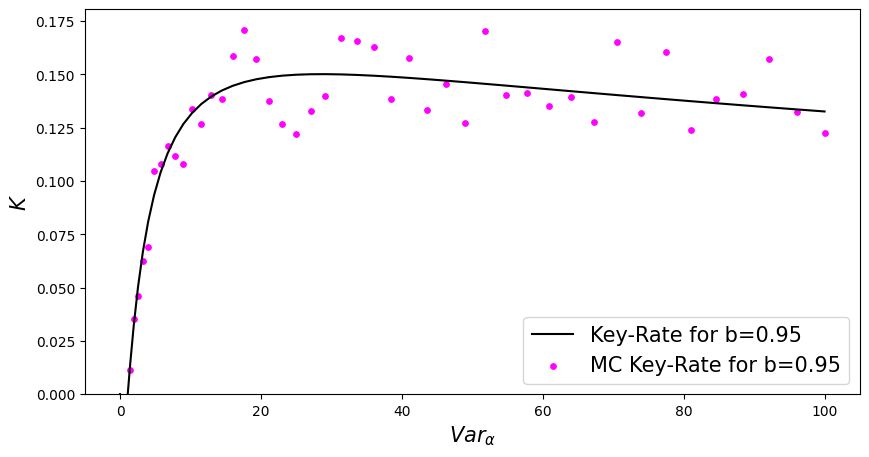

In [25]:
b = 0.95
size = 51
sigma_grid2 = np.linspace(0,10,5)
sigma_grid = np.linspace(0,10,size)
fig = plt.figure(figsize=(10,5), dpi=100)
plt.scatter(sigma_grid**2, I_grid_DR, s=15, color = 'magenta', label=r'$I_{AB}$ MC data')
#plt.scatter(sigma_grid2**2, holevo_grid[:5], s=15, color = 'blue', label = 'MC Holevo bound RR')
plt.plot(sigma_grid**2, qsf.theoretical_I_AB(sigma_grid**2, eta), '--' , color = 'magenta', label=r'$I_{AB}$ Theoretical curve')
plt.plot(sigma_grid**2, holevo_th_grid_DR, 'b--', label = 'Theoretical Holevo bound DR')
plt.xlabel(r'$Var_{{\alpha}}$', fontsize=15)
plt.ylabel(r'Information', fontsize=15)
plt.legend(fontsize=15)


b = 0.95
fig = plt.figure(figsize=(10,5), dpi=100)
plt.plot(sigma_grid**2, qsf.key_rate(b, qsf.theoretical_I_AB(sigma_grid**2, eta), holevo_th_grid_DR), 'k', label = f'Key-Rate for b={b}')
plt.scatter(sigma_grid**2, qsf.key_rate(b, I_grid_DR, holevo_th_grid_DR), s=15, color = 'magenta', label = f'MC Key-Rate for b={b}')
plt.xlabel(r'$Var_{{\alpha}}$', fontsize=15)
plt.ylim(0)
plt.ylabel(r'$K$', fontsize=15)
plt.legend(fontsize=15)
